# CVE to CWE Mapping

## Pre reqs:
CVE data is pulled from the Hugging Face dataset `regularpooria/NVD_CVE_699_Dataset`.
You still need to have ran scrape_cwe.ipynb so that `scrapers/scraped_data/CWE_SOFTWARE.json` exists.

### Requirements

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install sentence-transformers pandas tqdm matplotlib huggingface_hub

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 9.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 12.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 8.6 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface-hub]
    Found existing installation: tokenizers 0.22.20/3 [huggingface-hub]
    Uninstalling tokenizers-0.22.2:━━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled tokenizers-0.22.2 0/3 [huggingface-hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tokenizers]
    Found existing installation: transformers 4.56.2━━━━━━━━━━ 1/3 [tokeniz

In [1]:
import ast
import json
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from tqdm import tqdm

## Loading scraped data

In [ ]:
# BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
BASE_DIR = "../" # Local

### Loading CWE

In [2]:
!wget https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
with open(f"CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

--2026-10-05 20:47:51--  https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330024 (322K) [text/plain]
Saving to: ‘CWE_SOFTWARE.json’

CWE_SOFTWARE.json   100%[===================>] 322.29K  --.-KB/s    in 0.02s   

2026-10-05 20:47:51 (15.2 MB/s) - ‘CWE_SOFTWARE.json’ saved [330024/330024]



### Loading CVE

Loaded from the Hugging Face dataset `regularpooria/NVD_CVE_699_Dataset` (`NVD_CVE_Dataset.csv`), which already contains `true_children` and `true_categories`.

In [3]:
# CVE data comes from the published Hugging Face dataset.
HF_CVE_REPO_ID = "regularpooria/NVD_CVE_699_Dataset"
CVE = pd.read_csv(f"hf://datasets/{HF_CVE_REPO_ID}/NVD_CVE_Dataset.csv")

# true_children / true_categories are published as stringified lists -> parse them.
CVE["true_children"] = CVE["true_children"].apply(ast.literal_eval)
CVE["true_categories"] = CVE["true_categories"].apply(ast.literal_eval)

if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")
if (CVE["true_children"].str.len() == 0).any():
    raise ValueError("Some CVEs have a cwe_699_matches value that isn't a known child")

print(f"Loaded {len(CVE):,} CVE rows from {HF_CVE_REPO_ID}")

Loaded 88,146 CVE rows from regularpooria/NVD_CVE_699_Dataset


## CWE graph (root -> category -> child)
Used for children lookup and for finding the parent categories of a ground-truth CWE.


In [4]:
def make_graph(CWE):
    G = nx.DiGraph()
    G.add_node("root", type="main")
    for cat_id, category in CWE.items():
        G.add_node(cat_id, type="category", title=category["title"])
        G.add_edge("root", cat_id)
        for child_id, child in category["children"].items():
            if not G.has_node(child_id):  # a child can belong to several categories
                G.add_node(child_id, type="child", title=child["title"])
            G.add_edge(cat_id, child_id)
    return G

In [5]:
graph = make_graph(CWE)

category_ids = list(CWE.keys())
child_ids = [n for n, d in graph.nodes(data=True) if d["type"] == "child"]
child_pos = {cid: i for i, cid in enumerate(child_ids)}  # child id -> row in child matrix

# children (as row indices into the child matrix) for every category
category_child_rows = [
    [child_pos[c] for c in graph.successors(cat_id)] for cat_id in category_ids
]


def parents_of(child_id):
    return [p for p in graph.predecessors(child_id) if p != "root"]


## Embedding

In [6]:
!tar -xzf all_minilm_l6_v2_finetune_16bit.tar.gz

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.security.selinux'
tar: Ignoring un

In [9]:
!pip install -U "torchao>0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 59.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [10]:
embedding_model = SentenceTransformer("./all_minilm_l6_v2_finetune_16bit", model_kwargs={"torch_dtype": torch.float32})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

In [11]:
# CWE Embeddings - Slower because not batching but it's more readable

def extract_description(child):
    description = child["description"]
    if child["extended_description"] is not None:
        extended = child["extended_description"]
        description += f"\n{extended}"
    return description

child_lookup = {}
for category in CWE.values():
    for child_id, child in category["children"].items():
        child_lookup.setdefault(child_id, child)

child_embeddings = embedding_model.encode(
    [extract_description(child_lookup[cid]) for cid in child_ids],
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True,
)

category_embeddings = []
for cat_id in tqdm(category_ids):
    category = CWE[cat_id]
    child_titles = [child["title"] for child in category["children"].values()]
    text = category["title"] + ",".join(child_titles) + category["summary"]
    category_embeddings.append(embedding_model.encode(text, convert_to_tensor=True))
category_embeddings = torch.stack(category_embeddings)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:01<00:00, 35.36it/s]


In [12]:
if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")

cve_embeddings = embedding_model.encode(
    CVE["description"].tolist(), batch_size=64, show_progress_bar=True, convert_to_tensor=True
)

Batches:   0%|          | 0/1378 [00:00<?, ?it/s]

In [13]:
# just making sure
child_embeddings = child_embeddings.float()
category_embeddings = category_embeddings.float()
cve_embeddings = cve_embeddings.float()

In [14]:
torch.save(
    {
        "category_ids": category_ids,
        "category_embeddings": category_embeddings,
        "child_ids": child_ids,
        "child_embeddings": child_embeddings,
        "cve_embeddings": cve_embeddings,
    },
    "embeddings/embeddings.pt",
)

## Ground truth
`true_children` and `true_categories` are taken directly from the Hugging Face dataset.
`true_children` holds the numeric CWE-699 child ids and `true_categories` their parent category ids.

## Stage 1: rank categories


In [15]:
category_scores = cos_sim(cve_embeddings, category_embeddings)  # (n_cve, n_cat)

ranked_cat_idx = category_scores.argsort(dim=1, descending=True)
CVE["top_categories"] = [[category_ids[i] for i in row] for row in ranked_cat_idx.tolist()]


## Stage 2: rank children inside the top-BEAM categories
Level 1 = categories, level 2 = children.
Visit categories best-first. Inside each category rank its children by similarity.
The final list is: all children of category #1, then all children of category #2, ...
(no score mixing, the category guess decides the order of the blocks).



In [16]:
BEAM = 3  # how many categories to visit, in rank order (None = visit all of them)


def hierarchical_search(cve_emb, cat_scores, beam=BEAM):
    n = cve_emb.shape[0]
    beam = len(category_ids) if beam is None else min(beam, len(category_ids))
    top_idx = cat_scores.topk(beam, dim=1).indices  # (n, beam), best category first

    # Level 2, batched per category: (cve_idx, cat_idx) -> [(child_id, score), ...] best first
    per_cat = {}
    for ci, child_rows in enumerate(category_child_rows):
        if not child_rows:
            continue
        cve_rows = (top_idx == ci).any(dim=1).nonzero().squeeze(1)
        if len(cve_rows) == 0:
            continue

        scores = cos_sim(cve_emb[cve_rows], child_embeddings[child_rows])
        order = scores.argsort(dim=1, descending=True)
        for r, cve_idx in enumerate(cve_rows.tolist()):
            per_cat[(cve_idx, ci)] = [
                (child_ids[child_rows[j]], scores[r, j].item()) for j in order[r].tolist()
            ]

    # Walk the categories in rank order and concatenate their children
    ranked = []
    for cve_idx in range(n):
        seen, out = set(), []
        for ci in top_idx[cve_idx].tolist():
            for child_id, score in per_cat.get((cve_idx, ci), []):
                if child_id not in seen:  # a child can sit under several categories
                    seen.add(child_id)
                    out.append((child_id, score))
        ranked.append(out)
    return ranked


In [17]:
ranked_children = hierarchical_search(cve_embeddings, category_scores)
CVE["top_children"] = [[cid for cid, _ in row] for row in ranked_children]
CVE["top_children_scores"] = [[s for _, s in row] for row in ranked_children]

In [18]:
# Flat baseline: search every child directly, no category step
flat_scores = cos_sim(cve_embeddings, child_embeddings)
flat_ranked = flat_scores.argsort(dim=1, descending=True).tolist()
CVE["top_children_flat"] = [[child_ids[i] for i in row] for row in flat_ranked]

In [19]:
CVE.head(5)

,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,true_children,true_categories,top_categories,top_children,top_children_scores,top_children_flat
0,CVE-2023-0028,2023-01-01T01:15:12.627,2026-06-17T05:24:37.547,2023,Cross-site Scripting (XSS) - Stored in GitHub ...,CWE-79,CWE-79,1,1,[79],[137],"[355, 1213, 452, 1227, 137, 557, 371, 429, 255...","[1021, 549, 1007, 356, 449, 448, 447, 357, 344...","[0.2920264005661011, 0.21085557341575623, 0.20...","[79, 1289, 472, 565, 117, 523, 140, 312, 601, ..."
1,CVE-2023-22451,2023-01-02T16:15:11.063,2026-06-17T05:35:28.713,2023,Kiwi TCMS is an open source test management sy...,CWE-521,CWE-521,1,1,[521],[255],"[355, 1211, 255, 452, 1213, 1212, 840, 19, 265...","[549, 1007, 449, 356, 1021, 357, 447, 448, 309...","[0.6045425534248352, 0.5314185619354248, 0.503...","[521, 620, 260, 1392, 798, 640, 262, 309, 1220..."
2,CVE-2023-0038,2023-01-03T14:15:10.390,2026-06-17T05:24:38.627,2023,"The ""Survey Maker – Best WordPress Survey Plug...",CWE-79,CWE-79,1,1,[79],[137],"[355, 1213, 452, 371, 557, 1227, 137, 255, 121...","[1021, 549, 356, 1007, 449, 447, 448, 357, 344...","[0.4445762038230896, 0.35676491260528564, 0.35...","[79, 1289, 472, 565, 641, 140, 117, 523, 807, ..."
3,CVE-2023-22456,2023-01-03T19:15:10.483,2026-06-17T05:35:29.547,2023,"ViewVC, a browser interface for CVS and Subver...",CWE-79,CWE-79,1,1,[79],[137],"[355, 137, 1218, 557, 1213, 438, 19, 1211, 100...","[1021, 356, 1007, 449, 447, 549, 448, 357, 79,...","[0.49043217301368713, 0.48847904801368713, 0.4...","[79, 1289, 472, 523, 140, 117, 565, 346, 167, ..."
4,CVE-2023-0046,2023-01-04T12:15:08.613,2026-06-17T05:24:39.563,2023,Improper Restriction of Names for Files and Ot...,CWE-641,CWE-641,1,1,[641],"[1215, 137, 399]","[1218, 19, 265, 438, 1226, 355, 389, 1219, 121...","[1284, 805, 131, 786, 120, 788, 125, 124, 787,...","[0.5775930881500244, 0.5068543553352356, 0.417...","[184, 1230, 425, 73, 183, 268, 538, 66, 289, 1..."


## Evaluation

In [20]:
def recall_at_k(truths, predictions, k):
    """Hit if ANY true id is in the top-k predictions."""
    return np.mean([bool(set(t) & set(p[:k])) for t, p in zip(truths, predictions)])


ks = [1, 2, 3, 5, 10]

cat_recall = [recall_at_k(CVE["true_categories"], CVE["top_categories"], k) for k in ks]
child_recall = [recall_at_k(CVE["true_children"], CVE["top_children"], k) for k in ks]
flat_recall = [recall_at_k(CVE["true_children"], CVE["top_children_flat"], k) for k in ks]

print(f"Stage 1 (category) recall@BEAM={BEAM}: "
      f"{recall_at_k(CVE['true_categories'], CVE['top_categories'], BEAM):.3f}  <- ceiling for stage 2")
print()
print(f"{'k':>3} | {'category':>8} | {'child (hier)':>12} | {'child (flat)':>12}")
for k, a, b, c in zip(ks, cat_recall, child_recall, flat_recall):
    print(f"{k:>3} | {a:>8.3f} | {b:>12.3f} | {c:>12.3f}")

Stage 1 (category) recall@BEAM=3: 0.576  <- ceiling for stage 2

  k | category | child (hier) | child (flat)
  1 |    0.337 |        0.268 |        0.629
  2 |    0.503 |        0.283 |        0.685
  3 |    0.576 |        0.291 |        0.708
  5 |    0.676 |        0.313 |        0.738
 10 |    0.849 |        0.452 |        0.780


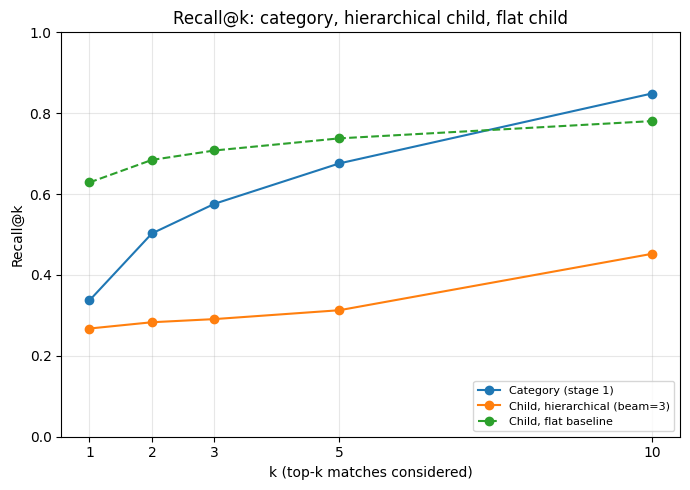

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(ks, cat_recall, marker="o", label="Category (stage 1)")
plt.plot(ks, child_recall, marker="o", label=f"Child, hierarchical (beam={BEAM})")
plt.plot(ks, flat_recall, marker="o", linestyle="--", label="Child, flat baseline")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Recall@k")
plt.title("Recall@k: category, hierarchical child, flat child")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Child recall@k given the category was found in the beam (isolates stage 2 quality)
in_beam = np.array([
    bool(set(t) & set(p[:BEAM])) for t, p in zip(CVE["true_categories"], CVE["top_categories"])
])
sub = CVE[in_beam]
print(f"Stage 2 child recall@k when the right category was in the beam ({in_beam.sum()} CVEs):")
for k in ks:
    print(f"  Recall@{k}: {recall_at_k(sub['true_children'], sub['top_children'], k):.3f}")


Stage 2 child recall@k when the right category was in the beam (50766 CVEs):
  Recall@1: 0.465
  Recall@2: 0.492
  Recall@3: 0.505
  Recall@5: 0.543
  Recall@10: 0.785


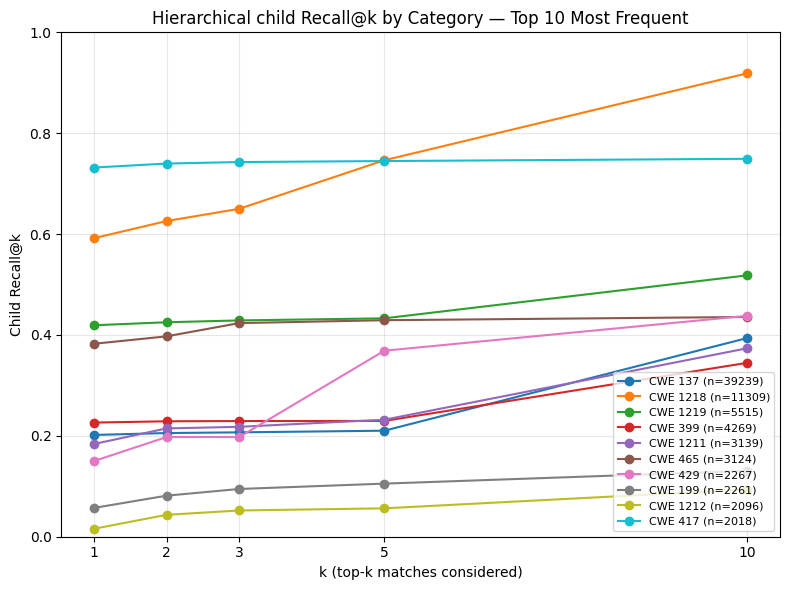

In [23]:
# Per-category child recall@1 / @5 for the 10 most frequent categories
CVE["primary_category"] = CVE["true_categories"].str[0]
top_cats = CVE["primary_category"].value_counts().head(10).index.tolist()

plt.figure(figsize=(8, 6))
for cat in top_cats:
    s = CVE[CVE["primary_category"] == cat]
    plt.plot(ks, [recall_at_k(s["true_children"], s["top_children"], k) for k in ks],
             marker="o", label=f"CWE {cat} (n={len(s)})")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Child Recall@k")
plt.title("Hierarchical child Recall@k by Category — Top 10 Most Frequent")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
def predict(description, beam=BEAM, top_n=5):
    emb = embedding_model.encode([description], convert_to_tensor=True)
    cat_scores = cos_sim(emb, category_embeddings)
    top = hierarchical_search(emb, cat_scores, beam)[0][:top_n]
    best_cat = category_ids[cat_scores.argmax().item()]
    print(f"Top category: CWE-{best_cat} - {graph.nodes[best_cat]['title']}")
    for cid, score in top:
        print(f"  CWE-{cid} ({score:.3f}) - {graph.nodes[cid]['title']}")


predict("A SQL injection vulnerability allows remote attackers to execute arbitrary queries via the id parameter.")

Top category: CWE-371 - State Issues
  CWE-1265 (0.395) - Unintended Reentrant Invocation of Non-reentrant Code Via Nested Calls
  CWE-374 (0.340) - Passing Mutable Objects to an Untrusted Method
  CWE-15 (0.335) - External Control of System or Configuration Setting
  CWE-375 (0.265) - Returning a Mutable Object to an Untrusted Caller
  CWE-372 (0.173) - Incomplete Internal State Distinction
